### Exploratory Data Analysis

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
train = pd.read_csv("../data/raw/Train.csv")
test = pd.read_csv("../data/raw/Test.csv")

#### 1. Target Class Analysis

In [7]:
print()
train['label'].value_counts()

label
0    1086
1     735
Name: count, dtype: int64

In [11]:
print()
train['label'].value_counts(normalize=True).mul(100).round(1)

label
0    59.6
1    40.4
Name: proportion, dtype: float64

The target distribution shows a slight class imbalance, with more non-aquaculture pond samples (59.6%) than aquaculture pond samples (40.4%). Both classes are sufficiently represented for model training.

#### 2. Class-wise Feature Mean Comparison

In [ ]:
class_mean = train.select_dtypes(include='number').groupby(train['label']).mean()
class_mean.T


label,0,1
VH_01,-24.494737,-26.687616
VV_01,-15.083692,-15.215269
blue_01,1541.928177,1813.525170
green_01,1680.123389,2090.610884
nir_01,2355.511050,2262.070748
...,...,...
re2_12,2254.792818,2057.108844
re3_12,2349.014733,2072.537415
red_12,1730.015654,1859.974150
swir1_12,2453.956722,1947.435374


The results show that the two groups (class 0 and class 1) have different average values for many satellite measurements. This means the two groups do not look the same from the satellite's point of view. Some features show bigger differences between the groups, so they may help the model tell the two classes apart. If class 1 represents ponds, the results suggest that ponds have a different reflection pattern compared with other areas, especially in water-sensitive bands like NIR and SWIR. These features should be studied more because they may be the most useful for identifying ponds.

#### 3. Feature Distribution

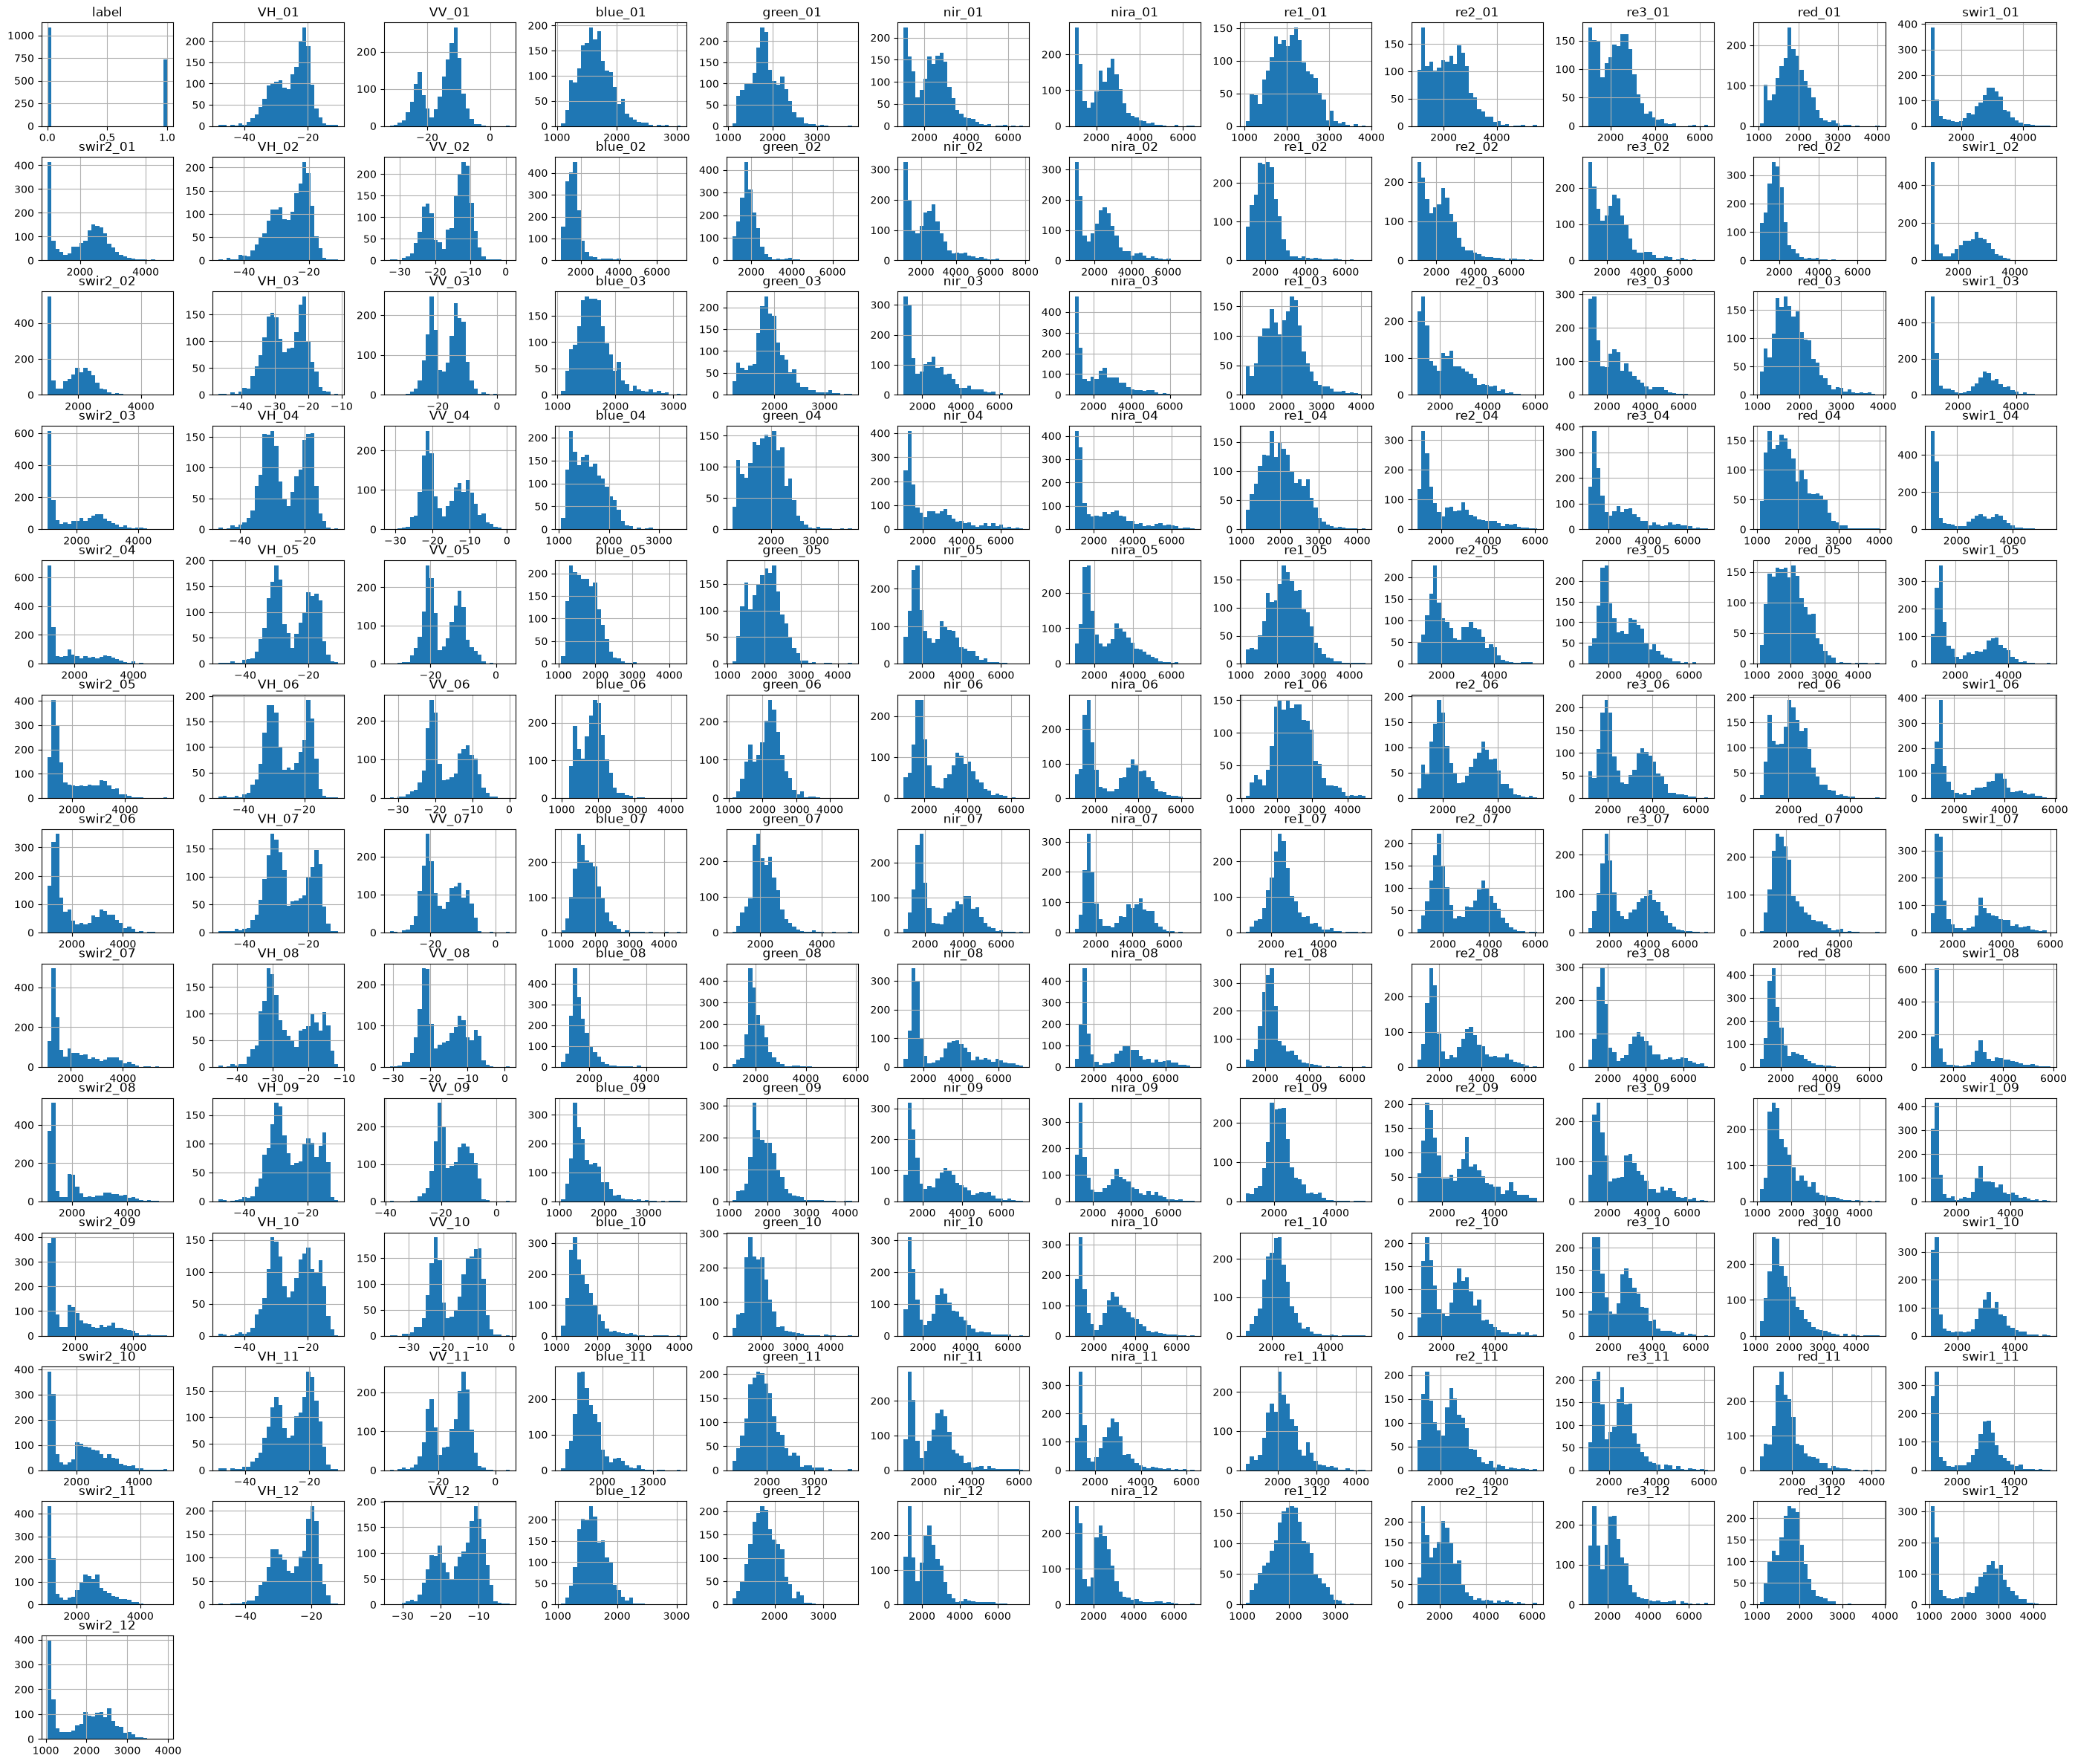

In [40]:
train.hist(figsize=(35,30), bins=30)
plt.show()


The feature distribution plots show that different features have different value patterns and ranges in the dataset. Most spectral bands, including **NIR, SWIR, Red, Green, and Blue**, as well as radar features (**VH and VV**), show different distributions, indicating that they capture different types of information from the data. Some features have values concentrated within a small range, while others have a wider spread. Many **NIR and SWIR features show right-skewed distributions**, where most values are low but some observations have very high values. Some features also show multiple peaks, which may indicate variations in different surface types or classes within the dataset. The **label distribution shows two distinct groups**, suggesting that the data is suitable for classification tasks. Overall, the feature distributions reveal useful variations among the variables; however, because the features have different scales and some show skewed distributions, **feature scaling or normalization is recommended before training machine learning models** to prevent features with larger values from dominating the learning process and to improve model performance.


#### 4. Feature–Target Correlation Matrix

In [39]:
corr = train.corr(numeric_only=True)

corr['label'].sort_values()


nira_08    -0.643898
nira_07    -0.642934
swir1_08   -0.630364
nira_09    -0.627880
nir_08     -0.626046
              ...   
blue_01     0.485605
green_12    0.488047
green_11    0.530583
green_01    0.569295
label       1.000000
Name: label, Length: 145, dtype: float64

The correlation analysis shows that several spectral features are strongly related to the target (`label`). Among them, **`nira_08` (-0.644)** has the strongest negative correlation, followed by **`nira_07`**, **`swir1_08`**, **`nira_09`**, and **`nir_08`**, indicating that higher values of these features are associated with lower target values. On the other hand, **`green_01` (0.569)** has the strongest positive correlation, followed by **`green_11`**, **`green_12`**, and **`blue_01`**, suggesting that higher values of these features are associated with higher target values. Overall, the results indicate that the NIR and SWIR spectral bands have the strongest relationships with the target and are likely to be important features for prediction.


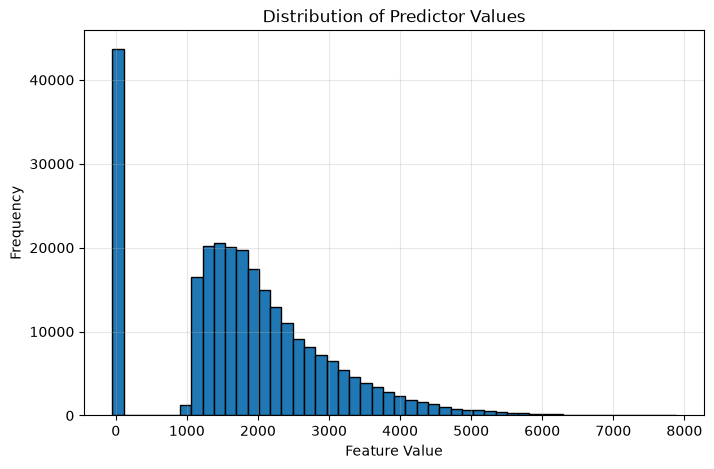

In [43]:
feature_columns = (
    train.select_dtypes(include=np.number)
    .drop(columns=['label'])
    .columns
)

plt.figure(figsize=(8, 5))

plt.hist(
    train[feature_columns].to_numpy().flatten(),
    bins=50,
    edgecolor='black'
)

plt.title("Distribution of Predictor Values")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()